In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# Load the dataset (update path if needed)
df = pd.read_excel(r"C:\Users\DELL\OneDrive\Desktop\coding\project\data\Online Retail.xlsx")

# See first 5 rows
print(df.head())

# Check shape & columns
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(df.info())
print(df.isnull().sum())  # Check missing values

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
Rows: 541909, Columns: 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
--- 

In [3]:
df = df.dropna(subset=['CustomerID'])
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
print(f'Clean dataset: {df.shape[0]} rows')

Clean dataset: 397884 rows


In [4]:
ref_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg({'InvoiceDate': lambda x: (ref_date - x.max()).days, 'InvoiceNo': 'nunique', 'TotalPrice': 'sum'}).reset_index()
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1,2,3,4])
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
print(rfm.head(10))

   CustomerID  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
0     12346.0      326          1  77183.60       1       1       4       114
1     12347.0        2          7   4310.00       4       4       4       444
2     12348.0       75          4   1797.24       2       3       4       234
3     12349.0       19          1   1757.55       3       1       4       314
4     12350.0      310          1    334.40       1       1       2       112
5     12352.0       36          8   2506.04       3       4       4       344
6     12353.0      204          1     89.00       1       1       1       111
7     12354.0      232          1   1079.40       1       1       3       113
8     12355.0      214          1    459.40       1       1       2       112
9     12356.0       23          3   2811.43       3       3       4       334


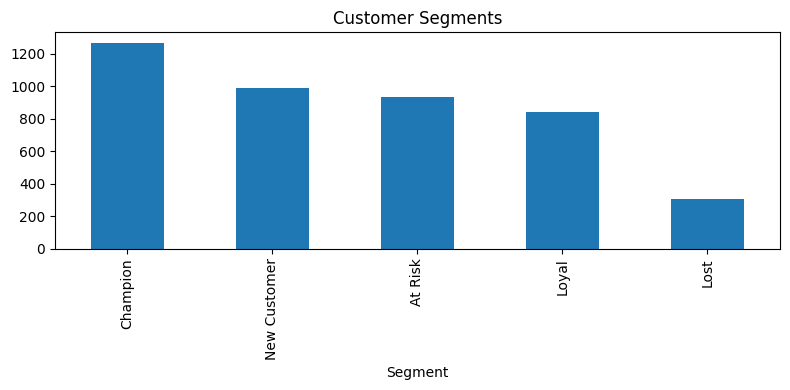

Saved rfm_output.csv


In [5]:
def segment(row):
    score = int(row['R_Score']) + int(row['F_Score']) + int(row['M_Score'])
    if score >= 10: return 'Champion'
    elif score >= 8: return 'Loyal'
    elif score >= 6: return 'At Risk'
    elif score >= 4: return 'New Customer'
    else: return 'Lost'
rfm['Segment'] = rfm.apply(segment, axis=1)
rfm['Segment'].value_counts().plot(kind='bar', figsize=(8,4), title='Customer Segments')
plt.tight_layout()
plt.savefig('segments.png', dpi=150)
plt.show()
rfm.to_csv('rfm_output.csv', index=False)
print('Saved rfm_output.csv')

In [7]:
monthly_revenue = df.groupby(
    df['InvoiceDate'].dt.to_period('M')
)['TotalPrice'].sum().reset_index()

monthly_revenue.columns = ['Month', 'Revenue']
monthly_revenue['Month'] = monthly_revenue['Month'].astype(str)
monthly_revenue = monthly_revenue.sort_values('Month')

monthly_revenue.to_csv(
    r"C:\Users\DELL\OneDrive\Desktop\coding\project\monthly_revenue.csv",
    index=False)
print("✅ Done!")

✅ Done!
